graph based risk aware aircraft colision avoidance using value iteration and policy iteration 

Graph-Risk MDP: Dynamic Programming Based Aircraft Collision Avoidance using OpenSky Encounter Data

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter,defaultdict
import os
import re
import json

In [3]:
df=pd.read_csv('opensky_collision_avoidance_dataset.csv')
df.head()

,time,own_icao24,intruder_icao24,own_latitude,own_longitude,own_geo_altitude_m,own_velocity_ms,own_heading_deg,own_vertical_rate_ms,intruder_latitude,...,intruder_vertical_rate_ms,relative_distance_km,relative_altitude_m,relative_speed_proxy_ms,distance_state,altitude_state,closing_state,mdp_state,recommended_action,reward
0,1781283492,06a081,4d238c,21.5555,114.0651,5844.54,216.48,193.61,6.83,22.1790,...,-2.60,77.029,-5044.44,113.36,far,below,approaching,far_below_approaching,maintain,5
1,1781283492,06a081,789239,21.5555,114.0651,5844.54,216.48,193.61,6.83,22.0067,...,-2.93,50.412,-3954.78,87.95,far,below,approaching,far_below_approaching,maintain,5
2,1781283492,06a081,78923f,21.5555,114.0651,5844.54,216.48,193.61,6.83,22.0112,...,-2.93,58.748,-3512.82,73.93,far,below,approaching,far_below_approaching,maintain,5
3,1781283492,06a081,789285,21.5555,114.0651,5844.54,216.48,193.61,6.83,21.9698,...,-2.60,46.128,-4221.48,89.61,far,below,approaching,far_below_approaching,maintain,5
4,1781283492,3c6717,0101dd,39.9681,116.8209,10066.02,261.74,353.00,-0.33,40.4816,...,7.80,61.726,-6629.40,80.91,far,below,approaching,far_below_approaching,maintain,5


In [4]:
df.shape

(102174, 24)

In [5]:
df.columns 

Index(['time', 'own_icao24', 'intruder_icao24', 'own_latitude',
       'own_longitude', 'own_geo_altitude_m', 'own_velocity_ms',
       'own_heading_deg', 'own_vertical_rate_ms', 'intruder_latitude',
       'intruder_longitude', 'intruder_geo_altitude_m', 'intruder_velocity_ms',
       'intruder_heading_deg', 'intruder_vertical_rate_ms',
       'relative_distance_km', 'relative_altitude_m',
       'relative_speed_proxy_ms', 'distance_state', 'altitude_state',
       'closing_state', 'mdp_state', 'recommended_action', 'reward'],
      dtype='object')

In [6]:
df['mdp_state'].nunique()

18

In [7]:
df['recommended_action'].value_counts()

recommended_action
maintain    100353
climb         1400
descend        421
Name: count, dtype: int64

lets make transitio 

In [8]:
df=df.sort_values(['own_icao24','intruder_icao24','time']).reset_index(drop=True)
df['next_state']=df.groupby(['own_icao24','intruder_icao24'])['mdp_state'].shift(-1)
df=df.dropna(subset=['next_state']).copy()

states=sorted(df['mdp_state'].unique())
actions=sorted(df['recommended_action'].unique())
print(f'number of states: {len(states)}')
print(f'number of actions: {len(actions)}')

number of states: 18
number of actions: 3


MDP probability 

In [9]:
transition_counts=defaultdict(Counter)
reward_values=defaultdict(list)

for _,row in df.iterrows():
    s=row['mdp_state']
    a=row['recommended_action']
    s_next=row['next_state']
    reward=row['reward']
    
    transition_counts[(s,a)][s_next]+=1
    reward_values[(s,a,s_next)].append(reward)
    
p={}
r={}
for key,counter in transition_counts.items():
    total=sum(counter.values())
    p[key]={s_next:count/total for s_next,count in counter.items()}
    
    
for key,rewards in reward_values.items():
    r[key]=np.mean(rewards)

value iteration 

policy dictionary 

In [21]:
gamma = 0.90
theta = 1e-6
max_iter = 1000

V = {s: 0.0 for s in states}
vi_deltas = []

for it in range(max_iter):
    delta = 0
    new_V = V.copy()

    for s in states:
        q_values = []

        for a in actions:
            if (s, a) not in p:
                continue

            q = 0
            for ns, prob in p[(s, a)].items():
                reward = r.get((s, a, ns), 0)
                q += prob * (reward + gamma * V[ns])

            q_values.append(q)

        if q_values:
            new_V[s] = max(q_values)
            delta = max(delta, abs(new_V[s] - V[s]))

    V = new_V
    vi_deltas.append(delta)

    if delta < theta:
        print("Converged:", it)
        break

V_value_iteration = V.copy()

print(V_value_iteration)

Converged: 0
{'far_above_approaching': 0.0, 'far_above_stable': 0.0, 'far_below_approaching': 0.0, 'far_below_stable': 0.0, 'far_same_approaching': 0.0, 'far_same_stable': 0.0, 'medium_above_approaching': 0.0, 'medium_above_stable': 0.0, 'medium_below_approaching': 0.0, 'medium_below_stable': 0.0, 'medium_same_approaching': 0.0, 'medium_same_stable': 0.0, 'near_above_approaching': 0.0, 'near_above_stable': 0.0, 'near_below_approaching': 0.0, 'near_below_stable': 0.0, 'near_same_approaching': 0.0, 'near_same_stable': 0.0}


In [10]:
gamma=0.99 
theta = 1e-6 
max_iter=1000

v={s:0 for s in states}
for it in range(max_iter):
    delta= 0 
    for s in states:
        q_values=[]
        
        for a in actions:
            if (s,a) not in p :
                q_values.append(-1e9)
                continue
            
            q=0 
            for ns ,prob in p[(s,a)].items():
                reward= r.get((s,a,ns),0)
                q+=prob*(reward + gamma * v[ns])
            q_values.append(q)
            
        best_value=max(q_values)
        delta=max(delta,abs(best_value-v[s]))
        v[s]=best_value
        
    if delta < theta:
        print(f'Value iteration converged after {it+1} iterations.')
        break
V = v.copy()

value_policy={}
for s in states:
    best_a = None 
    best_q = -1e9
    for a in actions:
        if (s,a) not in p:
            continue 
        q=0 
        for ns,prob in p[(s,a)].items():
            reward=r.get((s,a,ns),0)
            q+=prob*(reward + gamma * v[ns])
        if q > best_q:
            best_q=q
            best_a=a
    value_policy[s]=best_a
value_policy 

{'far_above_approaching': 'maintain',
 'far_above_stable': 'maintain',
 'far_below_approaching': 'maintain',
 'far_below_stable': 'maintain',
 'far_same_approaching': 'maintain',
 'far_same_stable': 'maintain',
 'medium_above_approaching': 'maintain',
 'medium_above_stable': 'maintain',
 'medium_below_approaching': 'maintain',
 'medium_below_stable': 'maintain',
 'medium_same_approaching': 'climb',
 'medium_same_stable': 'maintain',
 'near_above_approaching': 'climb',
 'near_above_stable': 'climb',
 'near_below_approaching': 'descend',
 'near_below_stable': 'descend',
 'near_same_approaching': 'climb',
 'near_same_stable': 'climb'}

policy iteration 

In [23]:
policy = {s: np.random.choice(actions) for s in states}

def policy_evaluation(policy, gamma=gamma, theta=theta):
    V = {s: 0.0 for s in states}

    while True:
        delta = 0

        for s in states:
            a = policy[s]

            if (s, a) not in p:
                continue

            old_v = V[s]
            new_v = 0

            for ns, prob in p[(s, a)].items():
                reward = r.get((s, a, ns), 0)
                new_v += prob * (reward + gamma * V[ns])

            V[s] = new_v
            delta = max(delta, abs(old_v - new_v))

        if delta < theta:
            break

    return V


def policy_improvement(V, policy, gamma=gamma):
    stable = True
    new_policy = policy.copy()

    for s in states:
        old_action = policy[s]

        best_a = None
        best_q = -1e9

        for a in actions:
            if (s, a) not in p:
                continue

            q = 0
            for ns, prob in p[(s, a)].items():
                reward = r.get((s, a, ns), 0)
                q += prob * (reward + gamma * V[ns])

            if q > best_q:
                best_q = q
                best_a = a

        if best_a is not None:
            new_policy[s] = best_a

        if new_policy[s] != old_action:
            stable = False

    return new_policy, stable


for it in range(100):
    V_pi = policy_evaluation(policy)
    new_policy, stable = policy_improvement(V_pi, policy, gamma=gamma)

    policy = new_policy

    if stable:
        print("Policy Iteration converged at iteration:", it)
        break

policy_iteration_policy = policy
policy_iteration_policy

Policy Iteration converged at iteration: 1


{'far_above_approaching': 'maintain',
 'far_above_stable': 'maintain',
 'far_below_approaching': 'maintain',
 'far_below_stable': 'maintain',
 'far_same_approaching': 'maintain',
 'far_same_stable': 'maintain',
 'medium_above_approaching': 'maintain',
 'medium_above_stable': 'maintain',
 'medium_below_approaching': 'maintain',
 'medium_below_stable': 'maintain',
 'medium_same_approaching': 'climb',
 'medium_same_stable': 'maintain',
 'near_above_approaching': 'climb',
 'near_above_stable': 'climb',
 'near_below_approaching': 'descend',
 'near_below_stable': 'descend',
 'near_same_approaching': 'climb',
 'near_same_stable': 'climb'}

making graph 

In [24]:
compare = pd.DataFrame({
    "state": states,
    "value_iteration_action": [value_policy[s] for s in states],
    "policy_iteration_action": [policy_iteration_policy[s] for s in states],
})

compare["same_policy"] = (
    compare["value_iteration_action"] == compare["policy_iteration_action"]
)

compare

,state,value_iteration_action,policy_iteration_action,same_policy
0,far_above_approaching,maintain,maintain,True
1,far_above_stable,maintain,maintain,True
2,far_below_approaching,maintain,maintain,True
3,far_below_stable,maintain,maintain,True
4,far_same_approaching,maintain,maintain,True
5,far_same_stable,maintain,maintain,True
6,medium_above_approaching,maintain,maintain,True
7,medium_above_stable,maintain,maintain,True
8,medium_below_approaching,maintain,maintain,True
9,medium_below_stable,maintain,maintain,True


In [25]:
state_values = globals().get('V', globals().get('v'))
if state_values is None:
    raise RuntimeError('Run the value iteration cell before building state_value_table.')

state_value_table = pd.DataFrame({
    "state": states,
    "optimal_value": [state_values[s] for s in states],
    "best_action_value_iteration": [value_policy[s] for s in states],
    "best_action_policy_iteration": [policy_iteration_policy[s] for s in states],
})

state_value_table.sort_values("optimal_value", ascending=False)

,state,optimal_value,best_action_value_iteration,best_action_policy_iteration
0,far_above_approaching,0.0,maintain,maintain
1,far_above_stable,0.0,maintain,maintain
16,near_same_approaching,0.0,climb,climb
15,near_below_stable,0.0,descend,descend
14,near_below_approaching,0.0,descend,descend
13,near_above_stable,0.0,climb,climb
12,near_above_approaching,0.0,climb,climb
11,medium_same_stable,0.0,maintain,maintain
10,medium_same_approaching,0.0,climb,climb
9,medium_below_stable,0.0,maintain,maintain


In [26]:
print(df["reward"].describe())
print(df["reward"].value_counts())

count    76670.000000
mean         4.289214
std          6.766401
min       -100.000000
25%          5.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: reward, dtype: float64
reward
 5      74844
-20       842
-2        713
-100      271
Name: count, dtype: int64


In [27]:
print("Number of transitions:", len(p))
print("Number of reward entries:", len(r))

sample_key = list(p.keys())[0]
print("Sample key:", sample_key)
print("Next states:", p[sample_key])

for ns, prob in p[sample_key].items():
    print(ns, prob, r.get((sample_key[0], sample_key[1], ns), 0))

Number of transitions: 18
Number of reward entries: 18
Sample key: ('far_above_approaching', 'maintain')
Next states: {'far_above_approaching': 0.8481950962761524, 'far_below_stable': 0.004912496162112374, 'medium_above_approaching': 0.05057239352603184, 'far_same_stable': 0.007982806263432606, 'far_above_stable': 0.0539497346374841, 'far_below_approaching': 0.010702223781744813, 'far_same_approaching': 0.014562042194833107, 'near_below_stable': 8.772314575200667e-05, 'medium_above_stable': 0.0035089258300802667, 'near_above_approaching': 0.00184218606079214, 'medium_same_stable': 0.0011404008947760867, 'medium_same_approaching': 0.0012281240405280934, 'medium_below_approaching': 0.00078950831176806, 'near_above_stable': 0.00021930786438001667, 'medium_below_stable': 0.00013158471862801, 'near_below_approaching': 4.3861572876003335e-05, 'near_same_stable': 0.00013158471862801}
far_above_approaching 0.8481950962761524 0
far_below_stable 0.004912496162112374 0
medium_above_approaching 0.

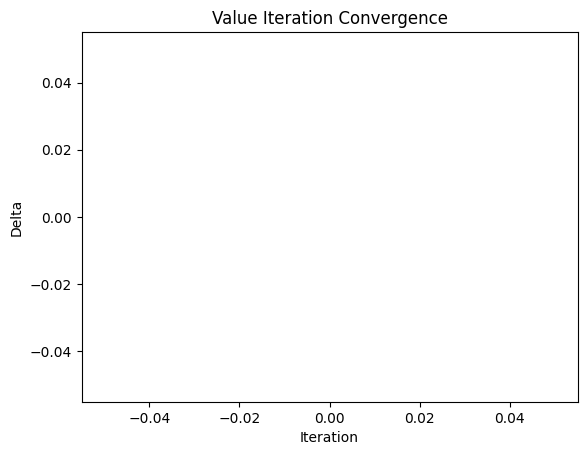

In [28]:
import matplotlib.pyplot as plt

plt.plot(vi_deltas)
plt.xlabel("Iteration")
plt.ylabel("Delta")
plt.title("Value Iteration Convergence")
plt.show()

Dataset shape: (102174, 24)
Index(['time', 'own_icao24', 'intruder_icao24', 'own_latitude',
       'own_longitude', 'own_geo_altitude_m', 'own_velocity_ms',
       'own_heading_deg', 'own_vertical_rate_ms', 'intruder_latitude',
       'intruder_longitude', 'intruder_geo_altitude_m', 'intruder_velocity_ms',
       'intruder_heading_deg', 'intruder_vertical_rate_ms',
       'relative_distance_km', 'relative_altitude_m',
       'relative_speed_proxy_ms', 'distance_state', 'altitude_state',
       'closing_state', 'mdp_state', 'recommended_action', 'reward'],
      dtype='object')
Total states: 18
Actions: ['climb', 'descend', 'maintain']
Reward distribution:
reward
 5      74844
-20       842
-2        713
-100      271
Name: count, dtype: int64
Transition entries: 18
Reward entries: 275
Value Iteration converged at iteration: 141
Policy Iteration converged at iteration: 0


,state,optimal_value_value_iteration,value_iteration_action,policy_iteration_action,same_policy
0,far_above_approaching,38.427125,maintain,maintain,True
2,far_below_approaching,38.262316,maintain,maintain,True
1,far_above_stable,35.522934,maintain,maintain,True
3,far_below_stable,35.151985,maintain,maintain,True
4,far_same_approaching,34.545633,maintain,maintain,True
5,far_same_stable,32.684241,maintain,maintain,True
6,medium_above_approaching,27.124144,maintain,maintain,True
8,medium_below_approaching,25.151145,maintain,maintain,True
12,near_above_approaching,24.525353,climb,climb,True
14,near_below_approaching,20.826998,descend,descend,True


Policy match rate: 1.0


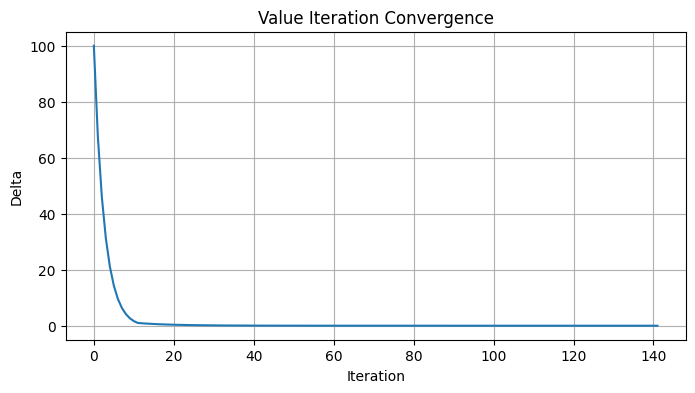

In [29]:
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

# =========================
# 1. Load Dataset
# =========================

df = pd.read_csv("opensky_collision_avoidance_dataset.csv")

print("Dataset shape:", df.shape)
print(df.columns)

# =========================
# 2. Sort and Create Next State
# =========================

df = df.sort_values(
    ["own_icao24", "intruder_icao24", "time"]
).reset_index(drop=True)

df["next_state"] = df.groupby(
    ["own_icao24", "intruder_icao24"]
)["mdp_state"].shift(-1)

df = df.dropna(subset=["next_state"]).copy()

states = sorted(df["mdp_state"].unique())
actions = sorted(df["recommended_action"].unique())

print("Total states:", len(states))
print("Actions:", actions)
print("Reward distribution:")
print(df["reward"].value_counts())

# =========================
# 3. Build Transition P(s'|s,a) and Reward R(s,a,s')
# =========================

transition_counts = defaultdict(Counter)
reward_values = defaultdict(list)

for _, row in df.iterrows():
    s = row["mdp_state"]
    a = row["recommended_action"]
    ns = row["next_state"]
    r = row["reward"]

    transition_counts[(s, a)][ns] += 1
    reward_values[(s, a, ns)].append(r)

P = {}
R = {}

for key, counter in transition_counts.items():
    total = sum(counter.values())
    P[key] = {ns: count / total for ns, count in counter.items()}

for key, rewards in reward_values.items():
    R[key] = np.mean(rewards)

print("Transition entries:", len(P))
print("Reward entries:", len(R))

# =========================
# 4. Value Iteration
# =========================

gamma = 0.90
theta = 1e-6
max_iter = 1000

V = {s: 0.0 for s in states}
vi_deltas = []

for it in range(max_iter):
    delta = 0
    new_V = V.copy()

    for s in states:
        q_values = []

        for a in actions:
            if (s, a) not in P:
                continue

            q = 0

            for ns, prob in P[(s, a)].items():
                reward = R.get((s, a, ns), 0)
                q += prob * (reward + gamma * V[ns])

            q_values.append(q)

        if q_values:
            new_V[s] = max(q_values)
            delta = max(delta, abs(new_V[s] - V[s]))

    V = new_V
    vi_deltas.append(delta)

    if delta < theta:
        print("Value Iteration converged at iteration:", it)
        break

V_value_iteration = V.copy()

value_policy = {}

for s in states:
    best_action = None
    best_q = -1e18

    for a in actions:
        if (s, a) not in P:
            continue

        q = 0

        for ns, prob in P[(s, a)].items():
            reward = R.get((s, a, ns), 0)
            q += prob * (reward + gamma * V_value_iteration[ns])

        if q > best_q:
            best_q = q
            best_action = a

    value_policy[s] = best_action

# =========================
# 5. Policy Iteration
# =========================

policy = {}

for s in states:
    available_actions = [a for a in actions if (s, a) in P]

    if available_actions:
        policy[s] = available_actions[0]
    else:
        policy[s] = None


def policy_evaluation(policy, gamma=0.90, theta=1e-6, max_eval_iter=1000):
    V_pi = {s: 0.0 for s in states}

    for _ in range(max_eval_iter):
        delta = 0
        new_V_pi = V_pi.copy()

        for s in states:
            a = policy[s]

            if a is None or (s, a) not in P:
                continue

            value = 0

            for ns, prob in P[(s, a)].items():
                reward = R.get((s, a, ns), 0)
                value += prob * (reward + gamma * V_pi[ns])

            new_V_pi[s] = value
            delta = max(delta, abs(new_V_pi[s] - V_pi[s]))

        V_pi = new_V_pi

        if delta < theta:
            break

    return V_pi


def policy_improvement(V_pi, policy):
    new_policy = policy.copy()
    stable = True

    for s in states:
        old_action = policy[s]
        best_action = None
        best_q = -1e18

        for a in actions:
            if (s, a) not in P:
                continue

            q = 0

            for ns, prob in P[(s, a)].items():
                reward = R.get((s, a, ns), 0)
                q += prob * (reward + gamma * V_pi[ns])

            if q > best_q:
                best_q = q
                best_action = a

        new_policy[s] = best_action

        if old_action != best_action:
            stable = False

    return new_policy, stable


pi_iterations = 0

for it in range(100):
    V_pi = policy_evaluation(policy)
    new_policy, stable = policy_improvement(V_pi, policy)

    policy = new_policy
    pi_iterations = it + 1

    if stable:
        print("Policy Iteration converged at iteration:", it)
        break

policy_iteration_policy = policy.copy()
V_policy_iteration = V_pi.copy()

# =========================
# 6. Final Table
# =========================

result_table = pd.DataFrame({
    "state": states,
    "optimal_value_value_iteration": [V_value_iteration[s] for s in states],
    "value_iteration_action": [value_policy[s] for s in states],
    "policy_iteration_action": [policy_iteration_policy[s] for s in states],
    "same_policy": [
        value_policy[s] == policy_iteration_policy[s]
        for s in states
    ]
})

result_table = result_table.sort_values(
    "optimal_value_value_iteration",
    ascending=False
)

display(result_table)

print("Policy match rate:",
      result_table["same_policy"].mean())

# =========================
# 7. Convergence Plot
# =========================

plt.figure(figsize=(8, 4))
plt.plot(vi_deltas)
plt.xlabel("Iteration")
plt.ylabel("Delta")
plt.title("Value Iteration Convergence")
plt.grid(True)
plt.show()

In [30]:
print("Unique states:", df["mdp_state"].nunique())
print("Actions:")
print(df["recommended_action"].value_counts())

print("Rewards:")
print(df["reward"].value_counts())

Unique states: 18
Actions:
recommended_action
maintain    75367
climb         952
descend       351
Name: count, dtype: int64
Rewards:
reward
 5      74844
-20       842
-2        713
-100      271
Name: count, dtype: int64


In [31]:
df = df.sort_values(
    ["own_icao24", "intruder_icao24", "time"]
).reset_index(drop=True)

df["next_state"] = df.groupby(
    ["own_icao24", "intruder_icao24"]
)["mdp_state"].shift(-1)

df = df.dropna(subset=["next_state"]).copy()

df[["own_icao24", "intruder_icao24", "time", "mdp_state", "recommended_action", "next_state", "reward"]].head(10)

,own_icao24,intruder_icao24,time,mdp_state,recommended_action,next_state,reward
0,0101dd,71bc19,1781283852,far_above_approaching,maintain,far_above_approaching,5
1,0101dd,71bc19,1781283950,far_above_approaching,maintain,far_above_approaching,5
2,0101dd,71bc19,1781284033,far_above_approaching,maintain,far_above_approaching,5
3,0101dd,71bc19,1781284133,far_above_approaching,maintain,far_below_stable,5
4,0101dd,71bc19,1781284553,far_below_stable,maintain,far_same_stable,5
5,0101dd,71bc19,1781284635,far_same_stable,maintain,medium_same_stable,5
7,040065,06a1ea,1781284313,far_above_stable,maintain,far_above_stable,5
9,040065,4ba94e,1781284313,medium_above_stable,maintain,near_above_stable,5
11,040065,4d0128,1781291489,far_above_stable,maintain,far_above_stable,5
12,040065,4d0128,1781291578,far_above_stable,maintain,far_above_stable,5


In [32]:
states = sorted(df["mdp_state"].unique())
actions = sorted(df["recommended_action"].unique())

print("Total states:", len(states))
print("Actions:", actions)

Total states: 18
Actions: ['climb', 'descend', 'maintain']


In [33]:
transition_counts = defaultdict(Counter)
reward_values = defaultdict(list)

for _, row in df.iterrows():
    s = row["mdp_state"]
    a = row["recommended_action"]
    ns = row["next_state"]
    r = row["reward"]

    transition_counts[(s, a)][ns] += 1
    reward_values[(s, a, ns)].append(r)

print("Transition count entries:", len(transition_counts))

Transition count entries: 18


In [34]:
P = {}
R = {}

for key, counter in transition_counts.items():
    total = sum(counter.values())
    P[key] = {ns: count / total for ns, count in counter.items()}

for key, rewards in reward_values.items():
    R[key] = np.mean(rewards)

print("P entries:", len(P))
print("R entries:", len(R))

P entries: 18
R entries: 265


In [35]:
sample_key = list(P.keys())[0]

print("Sample state-action:", sample_key)
print("Next state probabilities:")
print(P[sample_key])

print("\nRewards:")
for ns, prob in P[sample_key].items():
    print(ns, "prob:", prob, "reward:", R.get((sample_key[0], sample_key[1], ns), 0))

Sample state-action: ('far_above_approaching', 'maintain')
Next state probabilities:
{'far_above_approaching': 0.8245481453492034, 'far_below_stable': 0.005290005667863216, 'medium_above_approaching': 0.058378991120347626, 'far_same_stable': 0.00932048617671138, 'far_above_stable': 0.0627873291769003, 'far_below_approaching': 0.012154417784495245, 'far_same_approaching': 0.01643680332514642, 'near_below_stable': 6.297625795075257e-05, 'medium_above_stable': 0.0043453617986019275, 'near_above_approaching': 0.002330121544177845, 'medium_same_stable': 0.0012595251590150514, 'medium_same_approaching': 0.0016373827067195667, 'medium_below_approaching': 0.0007557150954090308, 'near_above_stable': 0.00031488128975376285, 'medium_below_stable': 0.0001889287738522577, 'near_below_approaching': 6.297625795075257e-05, 'near_same_stable': 0.00012595251590150514}

Rewards:
far_above_approaching prob: 0.8245481453492034 reward: 5.0
far_below_stable prob: 0.005290005667863216 reward: 5.0
medium_above

In [36]:
gamma = 0.90
theta = 1e-6
max_iter = 1000

V = {s: 0.0 for s in states}
vi_deltas = []

for it in range(max_iter):
    delta = 0
    new_V = V.copy()

    for s in states:
        q_values = []

        for a in actions:
            if (s, a) not in P:
                continue

            q = 0
            for ns, prob in P[(s, a)].items():
                reward = R.get((s, a, ns), 0)
                q += prob * (reward + gamma * V[ns])

            q_values.append(q)

        if q_values:
            new_V[s] = max(q_values)
            delta = max(delta, abs(new_V[s] - V[s]))

    V = new_V
    vi_deltas.append(delta)

    if delta < theta:
        print("Value Iteration converged at:", it)
        break

V_value_iteration = V.copy()
V_value_iteration

Value Iteration converged at: 144


{'far_above_approaching': 41.48881499776641,
 'far_above_stable': 40.376347822432514,
 'far_below_approaching': 41.83670577705667,
 'far_below_stable': 39.81359264809222,
 'far_same_approaching': 38.19498661749777,
 'far_same_stable': 37.84701819070323,
 'medium_above_approaching': 34.211991481957035,
 'medium_above_stable': 24.972538920178224,
 'medium_below_approaching': 35.36328634022659,
 'medium_below_stable': 22.974528252157043,
 'medium_same_approaching': -29.2054764614563,
 'medium_same_stable': -34.930737805992216,
 'near_above_approaching': 29.413665655714176,
 'near_above_stable': 15.40344354690597,
 'near_below_approaching': 29.315083274107653,
 'near_below_stable': 15.745126339004832,
 'near_same_approaching': -135.77222812400544,
 'near_same_stable': -178.1695553812293}

In [37]:
value_policy = {}

for s in states:
    best_action = None
    best_q = -1e18

    for a in actions:
        if (s, a) not in P:
            continue

        q = 0
        for ns, prob in P[(s, a)].items():
            reward = R.get((s, a, ns), 0)
            q += prob * (reward + gamma * V_value_iteration[ns])

        if q > best_q:
            best_q = q
            best_action = a

    value_policy[s] = best_action

value_policy

{'far_above_approaching': 'maintain',
 'far_above_stable': 'maintain',
 'far_below_approaching': 'maintain',
 'far_below_stable': 'maintain',
 'far_same_approaching': 'maintain',
 'far_same_stable': 'maintain',
 'medium_above_approaching': 'maintain',
 'medium_above_stable': 'maintain',
 'medium_below_approaching': 'maintain',
 'medium_below_stable': 'maintain',
 'medium_same_approaching': 'climb',
 'medium_same_stable': 'maintain',
 'near_above_approaching': 'climb',
 'near_above_stable': 'climb',
 'near_below_approaching': 'descend',
 'near_below_stable': 'descend',
 'near_same_approaching': 'climb',
 'near_same_stable': 'climb'}

In [38]:
policy = {}

for s in states:
    available_actions = [a for a in actions if (s, a) in P]
    policy[s] = available_actions[0] if available_actions else None

policy

{'far_above_approaching': 'maintain',
 'far_above_stable': 'maintain',
 'far_below_approaching': 'maintain',
 'far_below_stable': 'maintain',
 'far_same_approaching': 'maintain',
 'far_same_stable': 'maintain',
 'medium_above_approaching': 'maintain',
 'medium_above_stable': 'maintain',
 'medium_below_approaching': 'maintain',
 'medium_below_stable': 'maintain',
 'medium_same_approaching': 'climb',
 'medium_same_stable': 'maintain',
 'near_above_approaching': 'climb',
 'near_above_stable': 'climb',
 'near_below_approaching': 'descend',
 'near_below_stable': 'descend',
 'near_same_approaching': 'climb',
 'near_same_stable': 'climb'}

In [39]:
def policy_evaluation(policy, gamma=0.90, theta=1e-6, max_eval_iter=1000):
    V_pi = {s: 0.0 for s in states}

    for _ in range(max_eval_iter):
        delta = 0
        new_V_pi = V_pi.copy()

        for s in states:
            a = policy[s]

            if a is None or (s, a) not in P:
                continue

            value = 0

            for ns, prob in P[(s, a)].items():
                reward = R.get((s, a, ns), 0)
                value += prob * (reward + gamma * V_pi[ns])

            new_V_pi[s] = value
            delta = max(delta, abs(new_V_pi[s] - V_pi[s]))

        V_pi = new_V_pi

        if delta < theta:
            break

    return V_pi

In [40]:
def policy_improvement(V_pi, policy):
    new_policy = policy.copy()
    stable = True

    for s in states:
        old_action = policy[s]
        best_action = None
        best_q = -1e18

        for a in actions:
            if (s, a) not in P:
                continue

            q = 0

            for ns, prob in P[(s, a)].items():
                reward = R.get((s, a, ns), 0)
                q += prob * (reward + gamma * V_pi[ns])

            if q > best_q:
                best_q = q
                best_action = a

        new_policy[s] = best_action

        if old_action != best_action:
            stable = False

    return new_policy, stable

In [41]:
for it in range(100):
    V_pi = policy_evaluation(policy)
    new_policy, stable = policy_improvement(V_pi, policy)

    policy = new_policy

    if stable:
        print("Policy Iteration converged at:", it)
        break

policy_iteration_policy = policy.copy()
V_policy_iteration = V_pi.copy()

policy_iteration_policy

Policy Iteration converged at: 0


{'far_above_approaching': 'maintain',
 'far_above_stable': 'maintain',
 'far_below_approaching': 'maintain',
 'far_below_stable': 'maintain',
 'far_same_approaching': 'maintain',
 'far_same_stable': 'maintain',
 'medium_above_approaching': 'maintain',
 'medium_above_stable': 'maintain',
 'medium_below_approaching': 'maintain',
 'medium_below_stable': 'maintain',
 'medium_same_approaching': 'climb',
 'medium_same_stable': 'maintain',
 'near_above_approaching': 'climb',
 'near_above_stable': 'climb',
 'near_below_approaching': 'descend',
 'near_below_stable': 'descend',
 'near_same_approaching': 'climb',
 'near_same_stable': 'climb'}

In [42]:
result_table = pd.DataFrame({
    "state": states,
    "optimal_value": [V_value_iteration[s] for s in states],
    "value_iteration_action": [value_policy[s] for s in states],
    "policy_iteration_action": [policy_iteration_policy[s] for s in states],
})

result_table["same_policy"] = (
    result_table["value_iteration_action"] ==
    result_table["policy_iteration_action"]
)

result_table = result_table.sort_values("optimal_value", ascending=False)

display(result_table)

print("Policy match rate:", result_table["same_policy"].mean())

,state,optimal_value,value_iteration_action,policy_iteration_action,same_policy
2,far_below_approaching,41.836706,maintain,maintain,True
0,far_above_approaching,41.488815,maintain,maintain,True
1,far_above_stable,40.376348,maintain,maintain,True
3,far_below_stable,39.813593,maintain,maintain,True
4,far_same_approaching,38.194987,maintain,maintain,True
5,far_same_stable,37.847018,maintain,maintain,True
8,medium_below_approaching,35.363286,maintain,maintain,True
6,medium_above_approaching,34.211991,maintain,maintain,True
12,near_above_approaching,29.413666,climb,climb,True
14,near_below_approaching,29.315083,descend,descend,True


Policy match rate: 1.0


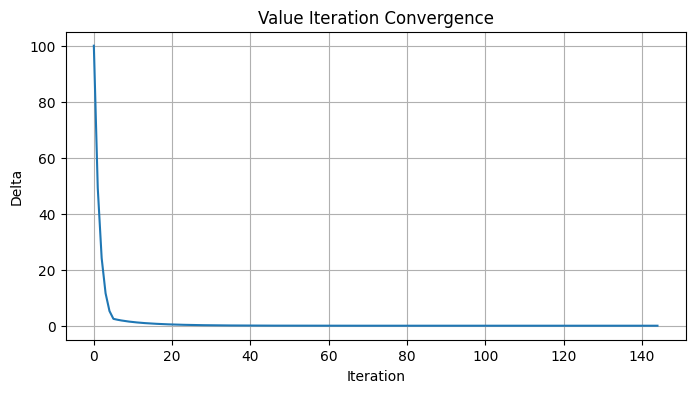

In [43]:
plt.figure(figsize=(8, 4))
plt.plot(vi_deltas)
plt.xlabel("Iteration")
plt.ylabel("Delta")
plt.title("Value Iteration Convergence")
plt.grid(True)
plt.show()